In [ ]:
# Setup para Google Colab (rode esta célula primeiro)
import importlib.util
import subprocess
import sys

IN_COLAB = importlib.util.find_spec("google.colab") is not None

# Stack alinhado ao lock do repositório (evita conflitos binários no Colab)
REQUIRED = {
    "numpy": "2.4.5",
    "scipy": "1.17.1",
    "matplotlib": "3.10.9",
    "qiskit": "2.4.1",
    "qiskit-aer": "0.17.2",
    "pylatexenc": "2.10",
}

def _version(pkg_name):
    try:
        from importlib.metadata import version
        return version(pkg_name)
    except Exception:
        return None

if IN_COLAB:
    to_install = []
    for pkg, ver in REQUIRED.items():
        cur = _version(pkg)
        if cur != ver:
            to_install.append(f"{pkg}=={ver}")

    if to_install:
        print("Executando no Colab. Instalando dependências compatíveis...")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--upgrade",
            "--force-reinstall",
            *to_install,
        ])
        raise SystemExit(
            "Dependências atualizadas. Reinicie o runtime do Colab e rode esta célula novamente."
        )
    else:
        print("Dependências já estão na versão correta.")
else:
    print("Ambiente local detectado. Pulando instalação automática do Colab.")

import qiskit
import qiskit_aer
import matplotlib
import numpy
import scipy
import pylatexenc

print("Ambiente OK.")
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("pylatexenc:", pylatexenc.__version__)

ModuleNotFoundError: No module named 'google'

# Aula Prática 1 de Computação Quântica

A prática da computação quântica requer o conhecimento de ferramentas apropriadas para rodar algoritmos em computadores quânticos reais. Existem vários frameworks para isso, como o Cirq, Qiskit e OpenQASM (Open Quantum Assembly), além da biblioteca brasileira Ket. Neste notebook, vamos dar os primeiros passos para aprender Qiskit e OpenQASM, as ferramentas utilizadas pela plataforma de computação quântica da IBM. 

## Sumário

- [Objetivos](#objetivos)
- [Criando conta do IBM Cloud](#criando-conta-do-ibm-cloud)
- [Analisando os Computadores Quânticos](#analisando-os-computadores-quânticos)
- [IBM Composer](#ibm-composer)
- [Instalando o Qiskit](#instalando-o-qiskit)
- [Executando Circuitos Quânticos](#executando-circuitos-quânticos)

## Objetivos

- Criar conta do IBM cloud
    - Criar instance e chave API
    - Ver computadores quânticos disponíveis
        - Mostrar topologias e parâmetros relevantes
- Apresentar o IBM Composer
    - Mostrar circuito H-CNOT
        - Mostrar visualizações
        - Ver código em OpenQASM e Qiskit
- Instalar o Qiskit (ver vídeo da IBM)
    - Rodar circuito H-CNOT
        - Simulador sem ruído e com ruído
        - Computador quântico
            - Analisar transpilação
        - Analisar os erros entre caso sem ruído e real
    - Rodar circuito mais complicado (correcting guide)
        - Ver que os erros são piores
        - Analisar transpilação
        - Exercício: Conseguimos encontrar o limite de número de qubits e portas lógicas através do simulador com ruído? 
    - Exercício: Como criar um estado inicial arbitrário?

## 1. Criando conta do IBM Cloud

1. Entre em [IBM Cloud](https://quantum.cloud.ibm.com/)
   1. Crie sua conta
   2. Crie uma instância e dê-lhe um nome
   3. Crie uma chave API para uso local

## 2. Analisando os Computadores Quânticos

Vamos visualizar os computadores quânticos disponíveis na conta gratuita. Atualmente, os computadores disponíveis são os ``ibm_torino`` e ``ibm_brisbane``. Para mais informações sobre os parâmetros dos computadores da IBM, ver https://quantum.cloud.ibm.com/docs/en/guides/qpu-information. 

### 2.0 Roteiro Didático (prática rápida antes da teoria)

Nesta seção, vamos responder 3 perguntas de forma prática:

1. Como converter taxa de erro em fidelidade?
2. Como estimar a fidelidade total de um circuito?
3. Como consultar métricas reais de um backend (opcional)?

Execute as células abaixo na ordem. Se você não tiver conta IBM configurada, a parte opcional vai apenas avisar e seguir normalmente.

In [3]:
# Exemplo 1: convertendo erro em fidelidade
def error_to_fidelity(error_rate):
    return 1 - error_rate

# Valores típicos aproximados em hardware NISQ
erro_1q = 0.001      # 0.1%
erro_2q = 0.01       # 1%
erro_readout = 0.02  # 2%

print("Fidelidade 1Q:", error_to_fidelity(erro_1q))
print("Fidelidade 2Q:", error_to_fidelity(erro_2q))
print("Fidelidade readout:", error_to_fidelity(erro_readout))

Fidelidade 1Q: 0.999
Fidelidade 2Q: 0.99
Fidelidade readout: 0.98


In [4]:
# Exemplo 2: estimando fidelidade de um circuito simples
def fidelidade_circuito(n_1q, n_2q, n_readout, f_1q=0.999, f_2q=0.99, f_readout=0.98):
    return (f_1q ** n_1q) * (f_2q ** n_2q) * (f_readout ** n_readout)

# Circuito exemplo: 6 portas de 1 qubit, 2 portas de 2 qubits, 2 medições
F = fidelidade_circuito(n_1q=6, n_2q=2, n_readout=2)
print(f"Fidelidade estimada do circuito: {F:.4f} ({100*F:.2f}%)")

# Mini experimento para os alunos: altere n_2q e observe o impacto
for n_2q in [0, 1, 2, 4, 8]:
    F_n = fidelidade_circuito(n_1q=6, n_2q=n_2q, n_readout=2)
    print(f"n_2q={n_2q:>2} -> F={100*F_n:6.2f}%")

Fidelidade estimada do circuito: 0.9357 (93.57%)
n_2q= 0 -> F= 95.47%
n_2q= 1 -> F= 94.51%
n_2q= 2 -> F= 93.57%
n_2q= 4 -> F= 91.70%
n_2q= 8 -> F= 88.09%


In [5]:
# Exemplo 3 (opcional): consultar métricas reais de um backend IBM
try:
    from qiskit_ibm_runtime import QiskitRuntimeService

    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False)
    config = backend.configuration()
    props = backend.properties()

    print("Backend selecionado:", backend.name)
    print("Numero de qubits:", config.n_qubits)

    if props and props.gates:
        erros_2q = []
        for g in props.gates:
            if len(g.qubits) == 2:
                for p in g.parameters:
                    if p.name == "gate_error":
                        erros_2q.append(p.value)
        if erros_2q:
            print("Melhor 2Q error:", min(erros_2q))
            print("Pior 2Q error:", max(erros_2q))
            print("Media 2Q error:", sum(erros_2q) / len(erros_2q))
        else:
            print("Nao encontrei metricas de erro 2Q neste backend.")
    else:
        print("Propriedades de calibracao nao disponiveis no momento.")

except Exception as e:
    print("Consulta opcional nao executada.")
    print("Motivo:", e)
    print("Se quiser usar esta celula, configure primeiro sua conta IBM no ambiente.")

management.get:WARNING:2026-05-18 20:33:21,915: Loading default saved account


Backend selecionado: ibm_kingston
Numero de qubits: 156
Melhor 2Q error: 0.0010038916610229098
Pior 2Q error: 1
Media 2Q error: 0.039101376078705924


### 2.0.1 Desafio rápido para os alunos

1. No Exemplo 2, altere o número de portas de 2 qubits e compare o impacto na fidelidade.
2. Mantendo o mesmo circuito, altere apenas a fidelidade de readout para 0.95 e depois 0.99.
3. Explique em uma frase: por que portas de 2 qubits costumam dominar o erro total?

Sugestão: cada grupo pode testar um conjunto de parâmetros e compartilhar os resultados com a turma.

### 2.1 Topologia e Taxas de Erro

A topologia é representada pelo grafo de conectividade dos qubits no processador físico. Por exemplo, o grafo do ```ibm_torino``` pode ser visto na figura abaixo:

<img src="ibm_torino_readout_error_cz_calibrations_2025-10-15T11_22_21Z.png" width="70%">

Essa grafo mostra os 133 qubits disponíveis e as cores representam:
- Nós: taxa de erro de medir o estado de 1 qubit (`readout assignment error`)
- Arestas: taxa de erro de aplicação de portas de 2-qubits (`2Q error`)

As taxas de erro tipicamente são medidas utilizando-se variações de uma quantidade chamada `fidelidade`, que pode ser definida para estados e para portas lógicas.

### 2.2 Taxa de Erro de Portas de 2-qubits

O "2Q error (best)" nos computadores quânticos da IBM refere-se à **taxa de erro de portas de dois qubits (two-qubit gates)** - especificamente, a melhor taxa de erro entre todas as conexões de dois qubits disponíveis em um processador quântico específico.

#### Detalhes:

- **Portas de 2 qubits**: São operações quânticas que envolvem dois qubits simultaneamente, como a porta CNOT (Controlled-NOT) ou CZ (Controlled-Z). Essas portas são fundamentais para criar emaranhamento quântico e implementar algoritmos quânticos.

- **Taxa de erro**: Indica a probabilidade de que a operação não seja executada corretamente. Por exemplo, um "2Q error" de 0.01 (ou 1%) significa que há 1% de chance de erro ao executar uma porta de dois qubits.

- **(best)**: Como os qubits em um processador quântico têm diferentes níveis de conectividade e qualidade, o valor "best" indica a **melhor** (menor) taxa de erro entre todos os pares de qubits conectados naquele dispositivo.

#### Contexto de importância:

As portas de dois qubits geralmente têm taxas de erro **muito maiores** do que portas de um único qubit, tornando-as um dos principais limitadores da qualidade dos circuitos quânticos. Por isso, esse é um dos parâmetros mais importantes ao avaliar a qualidade de um computador quântico.

Quando você visualizar os computadores quânticos disponíveis no IBM Quantum Cloud (conforme mencionado no seu notebook), esse será um dos parâmetros-chave a observar para comparar diferentes dispositivos.

### 2.3 Fidelidade de Estados e Portas Lógicas

A **fidelidade** (fidelity) é uma métrica fundamental para quantificar a qualidade de operações quânticas. A IBM utiliza definições específicas para estados e portas lógicas.

#### **1. Fidelidade de Estados**

A fidelidade entre dois estados quânticos $\rho$ (estado real) e $\sigma$ (estado ideal) (matrizes de densidade) é definida como:

$$F(\rho, \sigma) = \left(\text{Tr}\sqrt{\sqrt{\sigma}\rho\sqrt{\sigma}}\right)^2$$

Para estados puros, isso se simplifica para:

$$F(|\psi\rangle, |\phi\rangle) = |\langle\psi|\phi\rangle|^2$$

**Interpretação:**
- **F = 1 (100%)**: Estados idênticos
- **F = 0 (0%)**: Estados completamente ortogonais
- **F ~ 0.99 (99%)**: Estado muito próximo do ideal (típico em bons qubits)

#### **2. Fidelidade de Portas Lógicas (Gate Fidelity)**

**Average Gate Fidelity:**

$$F_{avg} = \frac{1}{d+1}\left(1 + \sum_{i}\langle\psi_i|U_{ideal}^\dagger U_{real}|\psi_i\rangle\right)$$

Onde:
- $U_{ideal}$ = operação unitária ideal
- $U_{real}$ = operação unitária real implementada
- $d$ = dimensão do espaço de Hilbert
- A média é sobre todos os estados de entrada possíveis

#### **3. Relação com Taxas de Erro**

A IBM frequentemente reporta **erros** ao invés de fidelidades:

$$\text{Error Rate} = 1 - F$$

**Exemplos:**
- **Porta de 1 qubit**: Error ~ 0.001 → Fidelidade ~ 99.9%
- **Porta de 2 qubits (CZ/CNOT)**: Error ~ 0.01 → Fidelidade ~ 99%
- **Readout**: Error ~ 0.02 → Fidelidade de leitura ~ 98%

#### **4. Como a IBM Mede (Calibração)**

A IBM realiza **calibrações frequentes** (geralmente a cada 24h):

**Para portas de 1 qubit:**
- Usa **Randomized Benchmarking**: aplica sequências aleatórias de portas
- Mede a fidelidade média após N portas
- Extrai a fidelidade por porta

**Para portas de 2 qubits:**
- Usa **Interleaved Randomized Benchmarking**
- Isola o erro da porta específica (CZ, ECR)

**Para leitura (readout):**
- Prepara estados |0⟩ e |1⟩ conhecidos
- Mede múltiplas vezes
- Calcula P(0|1) e P(1|0)

#### **5. Métricas Reportadas pela IBM**

| Métrica | Descrição | Valor Típico |
|---------|-----------|--------------|
| **1Q Gate Error** | Erro médio de portas SX, X | 0.0003-0.001 |
| **2Q Gate Error** | Erro de portas CZ/ECR | 0.005-0.02 |
| **Readout Error** | Erro de medição | 0.01-0.05 |
| **T1** | Tempo de relaxação | 100-200 μs |
| **T2** | Tempo de coerência | 50-150 μs |

#### **6. Fidelidade Composta (Circuit Fidelity)**

Para um circuito completo com múltiplas portas:

$$F_{circuit} \approx \prod_{i} F_{gate_i} \times \prod_{j} F_{readout_j}$$

**Exemplo:** Circuito com 5 portas de 1Q (F=0.999) e 2 portas de 2Q (F=0.99):

$$F_{circuit} \approx (0.999)^5 \times (0.99)^2 \times (0.98) \approx 0.955 \text{ (95.5\%)}$$

Isso mostra como os erros se acumulam rapidamente em circuitos quânticos!

### 2.4 Referências

#### Fidelidade em Computação Quântica

1. **Jozsa, R. (1994).** "Fidelity for Mixed Quantum States." *Journal of Modern Optics*, 41(12), 2315-2323. DOI: [10.1080/09500349414552171](https://doi.org/10.1080/09500349414552171)

2. **Nielsen, M. A. (2002).** "A simple formula for the average gate fidelity." *Physics Letters A*, 303(4), 249-252. DOI: [10.1016/S0375-9601(02)01272-0](https://doi.org/10.1016/S0375-9601(02)01272-0)

3. **Nielsen, M. A., & Chuang, I. L. (2010).** *Quantum Computation and Quantum Information* (10th Anniversary Edition). Cambridge University Press. ISBN: 978-1107002173

4. **Gilchrist, A., Langford, N. K., & Nielsen, M. A. (2005).** "Distance measures to compare real and ideal quantum processes." *Physical Review A*, 71(6), 062310. DOI: [10.1103/PhysRevA.71.062310](https://doi.org/10.1103/PhysRevA.71.062310)

#### Randomized Benchmarking

4. **Knill, E., Leibfried, D., Reichle, R., et al. (2008).** "Randomized benchmarking of quantum gates." *Physical Review A*, 77(1), 012307. DOI: [10.1103/PhysRevA.77.012307](https://doi.org/10.1103/PhysRevA.77.012307)

5. **Magesan, E., Gambetta, J. M., & Emerson, J. (2011).** "Scalable and robust randomized benchmarking of quantum processes." *Physical Review Letters*, 106(18), 180504. DOI: [10.1103/PhysRevLett.106.180504](https://doi.org/10.1103/PhysRevLett.106.180504)

6. **Magesan, E., Gambetta, J. M., & Emerson, J. (2012).** "Characterizing quantum gates via randomized benchmarking." *Physical Review A*, 85(4), 042311. DOI: [10.1103/PhysRevA.85.042311](https://doi.org/10.1103/PhysRevA.85.042311)

#### Documentação IBM Quantum

7. **IBM Quantum Documentation.** "Processor and System Performance." Disponível em: [https://docs.quantum.ibm.com/](https://docs.quantum.ibm.com/)

8. **Qiskit Textbook.** "Error Mitigation" Disponível em: [https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/error-mitigation](https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/error-mitigation)

9. **Cross, A. W., Bishop, L. S., Sheldon, S., Nation, P. D., & Gambetta, J. M. (2019).** "Validating quantum computers using randomized model circuits." *Physical Review A*, 100(3), 032328. DOI: [10.1103/PhysRevA.100.032328](https://doi.org/10.1103/PhysRevA.100.032328)

#### Artigos de Revisão

10. **Preskill, J. (2018).** "Quantum Computing in the NISQ era and beyond." *Quantum*, 2, 79. DOI: [10.22331/q-2018-08-06-79](https://doi.org/10.22331/q-2018-08-06-79)

11. **Arute, F., Arya, K., Babbush, R., et al. (2019).** "Quantum supremacy using a programmable superconducting processor." *Nature*, 574(7779), 505-510. DOI: [10.1038/s41586-019-1666-5](https://doi.org/10.1038/s41586-019-1666-5)

# 3. Apresentar o IBM Composer

Vamos começar entrando na plataforma IBM Composer: https://quantum.cloud.ibm.com/composer 

## 3.1 Demonstração em circuitos simples

Nosso primeiro circuito involve apenas uma porta de Hadamard e uma CNOT. Como vimos em sala, esse circuito emaranha estados e produz os chamados estados de Bell. (Ir para o Composer).

Agora, vamos analisar o circuito em mais detalhes utilizando as ferramentas do `qiskit`. Os alunos irão fazer no colab, mas, em casa, podem fazer localmente criando um ambiente de Python apropriado.

In [ ]:
# Instalando as bibiliotecas necessárias
# !pip install qiskit qiskit-ibm-runtime pylatexenc

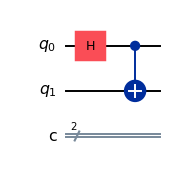

In [9]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from numpy import pi

qreg_q = QuantumRegister(2, 'q')
creg_c = ClassicalRegister(2, 'c')
circuit = QuantumCircuit(qreg_q, creg_c)

circuit.h(qreg_q[0])
circuit.cx(qreg_q[0], qreg_q[1])

circuit.draw('mpl', scale=0.7)

Podemos definir um vetor de estado para aplicarmos o circuito nele.

In [7]:
from qiskit.quantum_info import Statevector
import numpy as np
from numpy import sqrt

# Espaço de 2 qubits
ket0 = Statevector([0, 1, 0, 0])
ket1 = Statevector([1/sqrt(2), 0, 0, 1/sqrt(2)])

display(ket0.draw('latex'), ket1.draw('latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Fazendo uma medição do estado na base computacional.

In [ ]:
outcome, state = ket1.measure()
print(f"Medido: {outcome}\nEstado pós-medição:")

try:
    display(state.draw("latex"))
except Exception as e:
    print("Falha ao renderizar em LaTeX. Mostrando em texto.")
    print("Motivo:", e)
    display(state.draw("text"))

Medido: 00
Estado pós-medição:


<IPython.core.display.Latex object>

Evoluindo o estado com o circuito emaranhador:

In [77]:
v0 = ket0.evolve(circuit)
v1 = ket1.evolve(circuit)
display(v0.draw("latex"), v1.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Matriz do circuito:

In [76]:
from qiskit.quantum_info import Operator

display(Operator.from_circuit(circuit).draw("latex"))

<IPython.core.display.Latex object>

Obtendo a matriz do circuito através da multiplicação de matrizes:

In [62]:
H = Operator([[1/sqrt(2), 1/sqrt(2)], [1/sqrt(2), -1/sqrt(2)]])
CNOT = Operator([[1, 0, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0], [0, 1, 0, 0]])
display(CNOT.dot(Operator(np.eye(2)).tensor(H)).draw("latex"))

<IPython.core.display.Latex object>

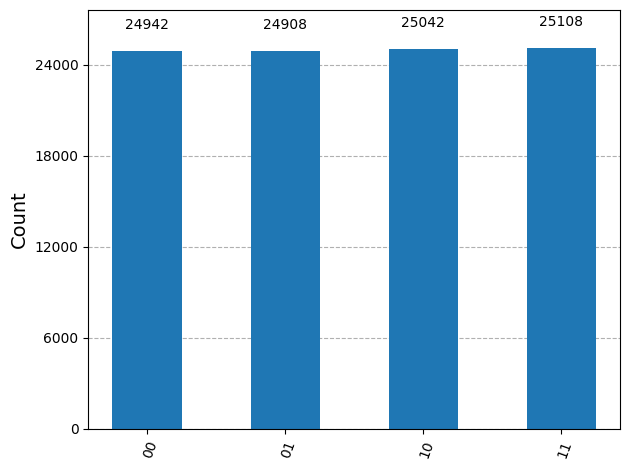

In [81]:
from qiskit.visualization import plot_histogram

statistics = v1.sample_counts(100000)
plot_histogram(statistics)

## 3.2 Rodando circuito em computador quântico

Vamos rodar primeiro usando o Composer. 